# Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBRegressor
pd.set_option('display.max_columns' , None)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Loading data

In [2]:
master_df = pd.read_csv("master_inventory_data.csv")

master_df.head()

,date,sku_id,units_sold,selling_price,gross_revenue,promo_flag,discount_pct,month,week_ofear,day_of_week,is_weekend,is_festival_month,is_payday_period,season_tag,holiday_flag,weather_index,campaign_intensity,platform_traffic_source,traffic_index,competitor_price_index,competitor_stockout_flag,bundle_offer_flag,stock_visibility_score,rating_score,review_volume,product_visibility_rank,lag_1_units,lag_7_units,lag_30_units,rolling_mean_7,rolling_meN_14,rolling_std_7,current_stock,safety_stock,reorder_point,lead_time_days,inbound_shipment_qty,supplier_id,supplier_name,avg_lead_time,lead_time_variability,current_stock.1,safety_stock.1,reorder_point.1,lead_time_days.1,inbound_shipment_qty.1,supplier_id.1
0,2024-01-01,SKU0001,28,1028.54,28799.12,0,0.0072,1,1,0,0,0,1,winter,0,1.033050,1,affiliate,1.028220,1.039897,0,0,0.332970,4.99,220,14,NaN,NaN,NaN,NaN,NaN,NaN,963,282,631,10,127,SUP003,Skyline Imports Pvt. Ltd.,10,2,963,282,631,10,127,SUP003
1,2024-01-02,SKU0001,27,942.76,25454.52,0,0.0900,1,1,1,0,0,1,winter,0,1.075864,0,organic,1.000124,1.034213,0,0,0.332574,4.99,220,26,28.0,NaN,NaN,NaN,NaN,NaN,963,282,631,10,127,SUP003,Skyline Imports Pvt. Ltd.,10,2,963,282,631,10,127,SUP003
2,2024-01-03,SKU0001,27,1023.78,27642.06,0,0.0118,1,1,2,0,0,1,winter,0,0.776739,0,paid,1.042157,1.019800,0,0,0.369938,4.99,220,50,27.0,NaN,NaN,NaN,NaN,NaN,963,282,631,10,127,SUP003,Skyline Imports Pvt. Ltd.,10,2,963,282,631,10,127,SUP003
3,2024-01-04,SKU0001,29,940.90,27286.10,0,0.0918,1,1,3,0,0,1,winter,0,1.029230,0,paid,0.998036,1.004657,0,0,0.445269,4.99,220,42,27.0,NaN,NaN,NaN,NaN,NaN,963,282,631,10,127,SUP003,Skyline Imports Pvt. Ltd.,10,2,963,282,631,10,127,SUP003
4,2024-01-05,SKU0001,37,812.43,30059.91,1,0.2158,1,1,4,0,0,1,winter,0,1.093677,1,organic,1.047220,0.956571,0,0,0.414885,4.99,220,20,29.0,NaN,NaN,NaN,NaN,NaN,963,282,631,10,127,SUP003,Skyline Imports Pvt. Ltd.,10,2,963,282,631,10,127,SUP003


In [3]:
rename_x = {
    col: col.replace("_x", "")
    for col in master_df.columns
    if "_x" in col
}

rename_y = {
    col: col.replace("_y", "")
    for col in master_df.columns
    if "_y" in col
}

master_df = master_df.rename(columns=rename_x)
master_df = master_df.rename(columns=rename_y)

In [4]:
master_df["date"] = pd.to_datetime(master_df["date"])

master_df = master_df.sort_values(
    ["sku_id", "date"]
)

# Creating lag and Rolling Features

In [ ]:
master_df["target_7d"] = (
    master_df
    .groupby("sku_id")["units_sold"]
    .shift(-7)
)

Random Forest, XGBoost, and production codebase. It explains the purpose of the feature engineering section and documents each lag feature clearly

In [ ]:
# Previous day's sales (1-day lag)
master_df["lag_1_units"] = (
    master_df.groupby("sku_id")["units_sold"].shift(1)
)

# Sales from one week ago (7-day lag)
master_df["lag_7_units"] = (
    master_df.groupby("sku_id")["units_sold"].shift(7)
)

# Sales from two weeks ago (14-day lag)
master_df["lag_14_units"] = (
    master_df.groupby("sku_id")["units_sold"].shift(14)
)

# Sales from three weeks ago (21-day lag)
master_df["lag_21_units"] = (
    master_df.groupby("sku_id")["units_sold"].shift(21)
)

# Sales from one month ago (30-day lag)
master_df["lag_30_units"] = (
    master_df.groupby("sku_id")["units_sold"].shift(30)
)

### Create Rolling Mean Features

In [ ]:
# Calculate the average sales over the previous 7 days
master_df["rolling_mean_7"] = (
    master_df.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

# Calculate the average sales over the previous 14 days
master_df["rolling_mean_14"] = (
    master_df.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

# Calculate the average sales over the previous 30 days
master_df["rolling_mean_30"] = (
    master_df.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

# Calculate the average sales over the previous 60 days
master_df["rolling_mean_60"] = (
    master_df.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(60).mean())
)

### Creating Rolling Rolling Features

Higher values indicate that demand is more volatile, while lower values indicate more stable demand. These features are particularly useful in inventory optimization because products with high demand variability often require higher safety stock to reduce the risk of stockouts.

In [ ]:
# Calculate the standard deviation of sales over the previous 7 days
master_df["rolling_std_7"] = (
    master_df.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

# Calculate the standard deviation of sales over the previous 30 days
master_df["rolling_std_30"] = (
    master_df.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(30).std())
)

# Calculate the standard deviation of sales over the previous 60 days
master_df["rolling_std_60"] = (
    master_df.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(60).std())
)

In [ ]:
sku_stats = (
    master_df.groupby("sku_id")["units_sold"].agg(sku_avg_demand="mean",sku_demand_std="std",sku_min_demand="min",sku_max_demand="max").reset_index()
)

master_df = master_df.merge(sku_stats,on="sku_id",how="left")

In [ ]:
categorical_cols = [
    "season_tag",
    "platform_traffic_source",
    'sku_id',
    'supplier_id',
]

for col in categorical_cols:

    encoder = LabelEncoder() # type: ignore
    master_df[col] = encoder.fit_transform(
        master_df[col]
    )

In [ ]:
drop_cols = [
    "date",
    "sku_name",
    "category",
    "sub_category",
    "supplier_name"      # only if present
]

drop_cols = [
    col for col in drop_cols
    if col in master_df.columns # type: ignore
]

master_df = master_df.drop(columns=drop_cols)

In [ ]:
master_df = master_df.dropna()

master_df.shape

(11960, 51)

In [ ]:
X = master_df.drop(
    columns=[
        "target_7d",
        "units_sold",
        "gross_revenue"
    ]
)

y = master_df["target_7d"]

In [ ]:
split_index = int(len(master_df) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

In [ ]:
master_df = master_df.drop(columns = [col for col in master_df.columns if col.endswith('.1')])

In [ ]:
xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred = xgb.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 3.94
RMSE : 5.05
R²   : 0.5856


In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
41,rolling_mean_60,0.253654
40,rolling_mean_30,0.098033
44,sku_avg_demand,0.050247
11,holiday_flag,0.039901
5,week_ofear,0.033891
46,sku_min_demand,0.030687
16,competitor_price_index,0.028049
8,is_festival_month,0.027267
15,traffic_index,0.026618
18,bundle_offer_flag,0.025793


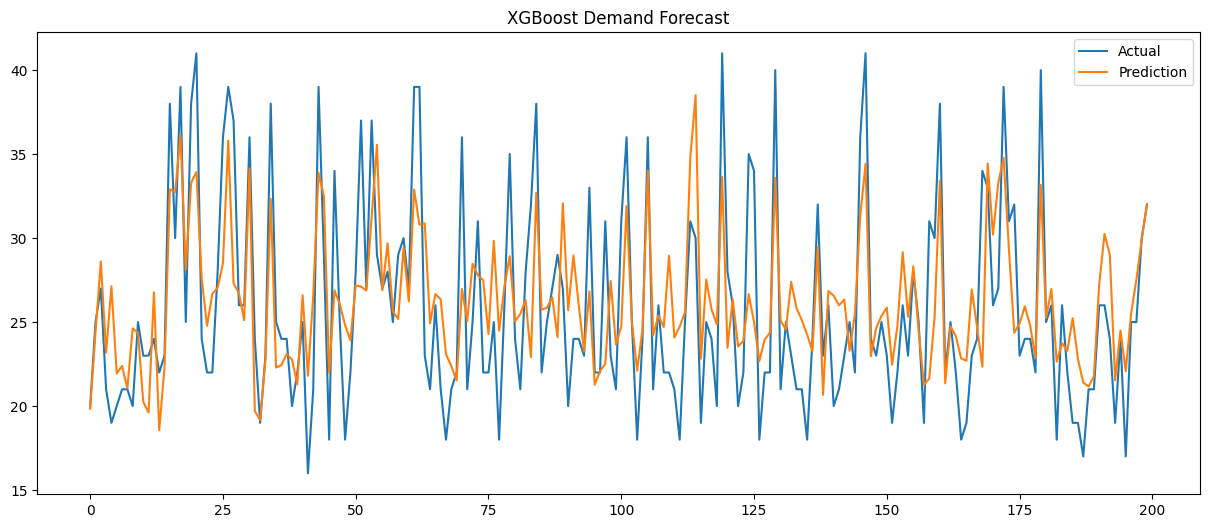

In [ ]:
results = pd.DataFrame({

    "Actual": y_test,

    "Prediction": y_pred

})

results = results.reset_index(drop=True)
plt.figure(figsize=(15,6))
plt.plot(results["Actual"][:200], label="Actual")
plt.plot(results["Prediction"][:200], label="Prediction")
plt.legend()
plt.title("XGBoost Demand Forecast")
plt.show()


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    "n_estimators": [200, 300, 500, 700],

    "max_depth": [3, 4, 5, 6, 8],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "min_child_weight": [1, 3, 5, 7],

    "gamma": [0, 0.1, 0.3, 0.5]
}

# Using Hyperparameter tuning in XGboost



In [ ]:
xgb = XGBRegressor(
    objective = 'reg:squarederror',
    random_state = 42
)

In [ ]:
# Initialize RandomizedSearchCV for hyperparameter optimization
random_search = RandomizedSearchCV(
    estimator=xgb,                               # Base XGBoost model
    param_distributions=param_grid,              # Hyperparameter search space
    n_iter=30,                                   # Number of random parameter combinations to evaluate
    scoring='neg_root_mean_squared_error',       # Optimize using RMSE (lower RMSE is better)
    cv=5,                                        # Perform 5-fold cross-validation
    verbose=2,                                   # Display training progress
    random_state=42,                             # Ensure reproducible results
    n_jobs=-1                                    # Use all available CPU cores
)

In [ ]:
random_search.fit(X_train , y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.03, max_depth=4, min_child_weight=7, n_estimators=200, subsample=1.0; total time=   1.0s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.03, max_depth=4, min_child_weight=7, n_estimators=200, subsample=1.0; total time=   1.0s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.03, max_depth=4, min_child_weight=7, n_estimators=200, subsample=1.0; total time=   1.0s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.03, max_depth=4, min_child_weight=7, n_estimators=200, subsample=1.0; total time=   1.0s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.03, max_depth=4, min_child_weight=7, n_estimators=200, subsample=1.0; total time=   1.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=3, n_estimators=700, subsample=0.7; total time=   6.0s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.05, max_dept

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
print("Best Parameters:\n")
print(random_search.best_params_) # This wll print the best parameters to use for model training 

Best Parameters:

{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 1.0}


In [ ]:
best_xgb = random_search.best_estimator_

In [ ]:
y_pred = best_xgb.predict(X_test) # type: ignore

In [ ]:
# Calculate Mean Absolute Error (MAE)
# Measures the average absolute difference between actual and predicted demand.
mae = mean_absolute_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
# Penalizes larger prediction errors more heavily than MAE.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate the Coefficient of Determination (R²)
# Measures how well the model explains the variation in the target variable.
r2 = r2_score(y_test, y_pred)

# Display the evaluation metrics
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 3.89
RMSE : 5.01
R²   : 0.5922


,Feature,Importance
41,rolling_mean_60,0.262718
40,rolling_mean_30,0.115134
11,holiday_flag,0.048287
44,sku_avg_demand,0.041560
5,week_ofear,0.037627
18,bundle_offer_flag,0.032515
16,competitor_price_index,0.028974
15,traffic_index,0.028036
4,month,0.025992
13,campaign_intensity,0.024908


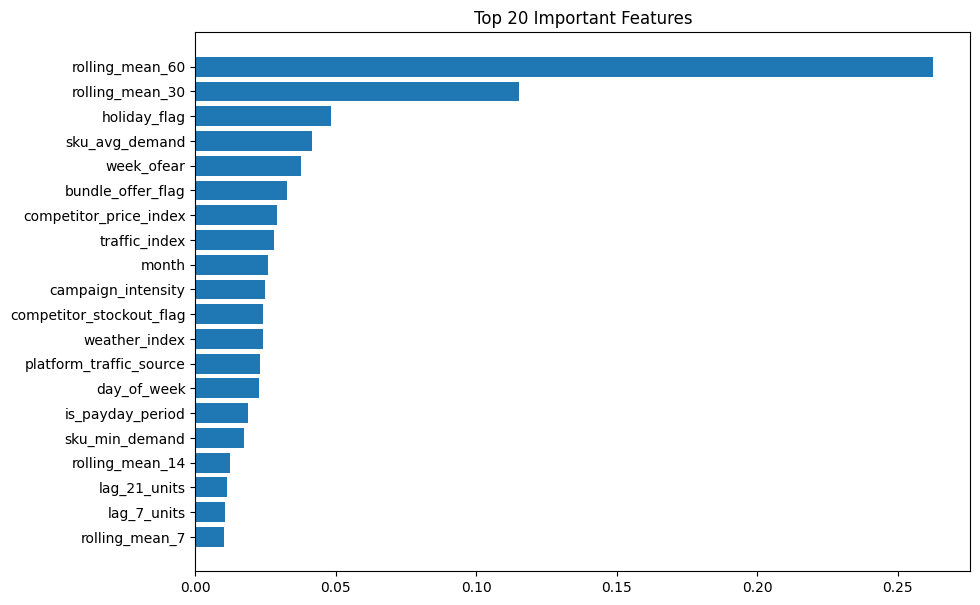

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_ # type: ignore
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(10,7))

plt.barh(importance["Feature"][:20][::-1], importance["Importance"][:20][::-1])

plt.title("Top 20 Important Features")
plt.show()

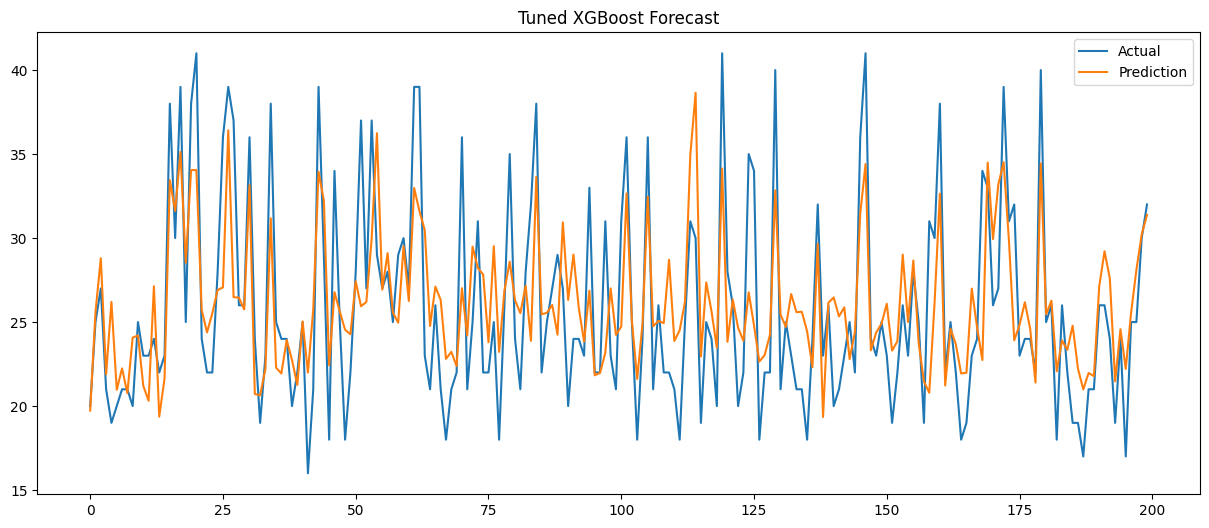

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    y_pred[:200],
    label="Prediction"
)

plt.title("Tuned XGBoost Forecast")

plt.legend()

plt.show()

## Conclusion
 > Hyperparameter tuning resulted in a marginal improvement in forecasting performance. The tuned XGBoost model achieved lower MAE and RMSE values while increasing the R² score from 0.5856 to 0.5922. This indicates that the optimized hyperparameters improved the model's ability to generalize, although the gains were modest, suggesting that the model was already close to its optimal performance on the available dataset.

In [ ]:
# Predict demand for all records
master_df["predicted_demand"] = best_xgb.predict(X) # type: ignore

In [ ]:
master_df.to_csv('master_df.csv', index=False)